### 開始模型部分

In [1]:
import csv

# 讀入文章集
content=list() #用串列預備儲存所有內容

f = open('bullishnews_ok.csv', newline='', encoding='utf-8') #開檔 
rows = csv.reader(f, delimiter=',') #讀檔
for row in rows: 
  content.append(row[0])
f.close()

f = open('bearishnews_ok.csv', newline='', encoding='utf-8') #開檔 
rows = csv.reader(f, delimiter=',') #讀檔
for row in rows:
  content.append(row[0])
f.close()

In [2]:
print(len(content)) #檢查總共有幾份內容

2148


In [ ]:
#用500個詞，重複只算一次

termset=dict() #用字典預備儲存所有詞彙
no=0 #幫詞彙編號

f = open('bullish_500words.csv', newline='', encoding='utf-8') #開檔 
rows = csv.reader(f, delimiter=',') #讀檔
for row in rows:
  if row[0] not in termset: #如果是新詞彙則加入(意思是重複的不列入)
    termset[row[0]]=no
    no+=1
f.close()

f = open('bearish_500words.csv', newline='', encoding='utf-8') #開檔 
rows = csv.reader(f, delimiter=',') #讀檔
for row in rows:
  if row[0] not in termset: #如果是新詞彙則加入(意思是重複的不列入)
    termset[row[0]]=no
    no+=1
f.close()

In [6]:
# 用1000個詞，只要重複就刪掉

termset=dict() #用字典預備儲存所有詞彙

f = open('bullish_1000words.csv', newline='', encoding='utf-8') #開檔 
rows = csv.reader(f, delimiter=',') #讀檔
for row in rows:
  if row[0] not in termset: #如果是新詞彙則加入(意思是重複的不列入)
    termset[row[0]]=0
f.close()

f = open('bearish_1000words.csv', newline='', encoding='utf-8') #開檔 
rows = csv.reader(f, delimiter=',') #讀檔
for row in rows:
  if row[0] not in termset: #如果是新詞彙則加入(意思是重複的不列入)
    termset[row[0]]=0
  else: del termset[row[0]]
f.close()

no=0 #幫詞彙編號
for term in termset:
  termset[term] = no
  no += 1

In [3]:
# 各用2000個詞，只要重複就刪掉

import itertools

use_words = 2000
termset = {}

with open('bullish_allwords.csv', newline='', encoding='utf-8') as f:
  rows = csv.reader(f, delimiter=',')
  # islice(rows, 2000) 會產生只含前 2000 行的迭代器
  for row in itertools.islice(rows, use_words):
    if row[0] not in termset:
      termset[row[0]] = 0
f.close()

with open('bearish_allwords.csv', newline='', encoding='utf-8') as f:
  rows = csv.reader(f, delimiter=',')
  # islice(rows, 2000) 會產生只含前 2000 行的迭代器
  for row in itertools.islice(rows, use_words):
    if row[0] not in termset:
      termset[row[0]] = 0
    else: del termset[row[0]]
f.close()

no=0 #幫詞彙編號
for term in termset:
  termset[term] = no
  no += 1

In [4]:
print(len(termset)) #檢查總共有幾個詞彙

602


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(vocabulary=termset,use_idf=True) #用給定的termset建構向量，並使用idf加權

In [6]:
X = vectorizer.fit_transform(content) #用給定的文件集做計算
X

c:\Users\jason\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\feature_extraction\text.py:1381: UserWarning: Upper case characters found in vocabulary while 'lowercase' is True. These entries will not be matched with any documents
  warnings.warn(


<2148x602 sparse matrix of type '<class 'numpy.float64'>'
	with 21164 stored elements in Compressed Sparse Row format>

In [10]:
from scipy import sparse
sparse.save_npz("limit_model.npz", X) #寫入整個稀疏矩陣

In [7]:
import pandas as pd
pd.DataFrame(X.toarray(),columns=termset) #將X印出做觀察

,董事,電能,合約,8210,改變,機殼,四月,母公司,事項,回穩,...,模式,失業率,穎漢,拉出,候選人,傳輸,增強,參加,房子,法官
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.091429,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.118115,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2143,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
2144,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
2145,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
2146,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0


In [8]:
import numpy as np

y=[] #用以儲存已知類別
for i in range(1003): #已知前1003篇為漲，標記為看漲 (此為取巧權宜作法)
  y.append(['看漲'])
for i in range(1145): #已知後1145篇為跌停，標記為看跌
  y.append(['看跌'])
y=np.ravel(y) #轉換成array避免警告訊息
pd.DataFrame(y) #將y印出做觀察

,0
0,看漲
1,看漲
2,看漲
3,看漲
4,看漲
...,...
2143,看跌
2144,看跌
2145,看跌
2146,看跌


In [9]:
# 作業6的做法

from sklearn.naive_bayes import MultinomialNB
#以下將自身資料切成train及test兩組，重新訓練一次，測試模型準確率
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1) #隨機挑選 size% 當測試資料
classifier = MultinomialNB()
classifier.fit(X_train, y_train) #訓練

from sklearn import metrics 
from sklearn.metrics import accuracy_score
y_pred= classifier.predict(X_test) #用測試資料預測
print("Accuracy:",metrics.accuracy_score(y_test, y_pred)) #比對答案，計算準確率

from sklearn.metrics import classification_report  
print(classification_report(y_test, y_pred)) #印出分類報告

from sklearn.metrics import confusion_matrix  
print(confusion_matrix(y_test, y_pred, labels=['看漲','看跌'])) #印出混淆矩陣
# test/predicted 看漲   看跌
#    看漲         TN     FP
#    看跌         FN     TP

Accuracy: 0.6604651162790698
              precision    recall  f1-score   support

          看漲       0.69      0.54      0.61       104
          看跌       0.64      0.77      0.70       111

    accuracy                           0.66       215
   macro avg       0.67      0.66      0.65       215
weighted avg       0.67      0.66      0.66       215

[[56 48]
 [25 86]]


In [10]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier                          
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

kf = KFold(n_splits=10, shuffle=True, random_state=42)  # 設定shuffle=True


classifier = MultinomialNB()
scores = cross_val_score(classifier,X,y,cv=kf,scoring='accuracy') #交叉驗證，計算準確率
print(scores)
print("NB Accuracy:",scores.mean())

classifier = DecisionTreeClassifier(criterion="entropy")
scores = cross_val_score(classifier,X,y,cv=kf,scoring='accuracy') #交叉驗證，計算準確率
print(scores)
print("DecisionTree Accuracy:",scores.mean())

classifier = KNeighborsClassifier(n_neighbors=7)
scores = cross_val_score(classifier,X,y,cv=kf,scoring='accuracy') #交叉驗證，計算準確率
print(scores)
print("KNN Accuracy:",scores.mean())

classifier = SVC(kernel='linear')
scores = cross_val_score(classifier,X,y,cv=kf,scoring='accuracy') #交叉驗證，計算準確率
print(scores)
print("SVC Accuracy:",scores.mean())

classifier = RandomForestClassifier(random_state=69)
scores = cross_val_score(classifier,X,y,cv=kf,scoring='accuracy') #交叉驗證，計算準確率
print(scores)
print("RF Accuracy:",scores.mean())

[0.6744186  0.72093023 0.69302326 0.66511628 0.78139535 0.68837209
 0.72093023 0.63255814 0.70560748 0.68224299]
NB Accuracy: 0.696459465333623
[0.66046512 0.65581395 0.6372093  0.66976744 0.68372093 0.68837209
 0.61395349 0.61395349 0.6635514  0.61214953]
DecisionTree Accuracy: 0.6498956748532926
[0.59069767 0.59534884 0.5255814  0.60465116 0.53953488 0.57209302
 0.62325581 0.57209302 0.56074766 0.60747664]
KNN Accuracy: 0.5791480113018908
[0.64186047 0.67906977 0.69302326 0.66046512 0.71162791 0.67906977
 0.68372093 0.66976744 0.70093458 0.6728972 ]
SVC Accuracy: 0.6792436426863725
[0.66511628 0.71162791 0.70232558 0.7255814  0.70232558 0.71627907
 0.66976744 0.72093023 0.68224299 0.68224299]
RF Accuracy: 0.6978439469680504


SVM Model Accuracy: 0.74
KNN Model Accuracy: 0.63
Decision Tree Model Accuracy: 0.64
Random Forest Model Accuracy: 0.72
MLP Model Accuracy: 0.71
Majority Voting Accuracy: 0.77


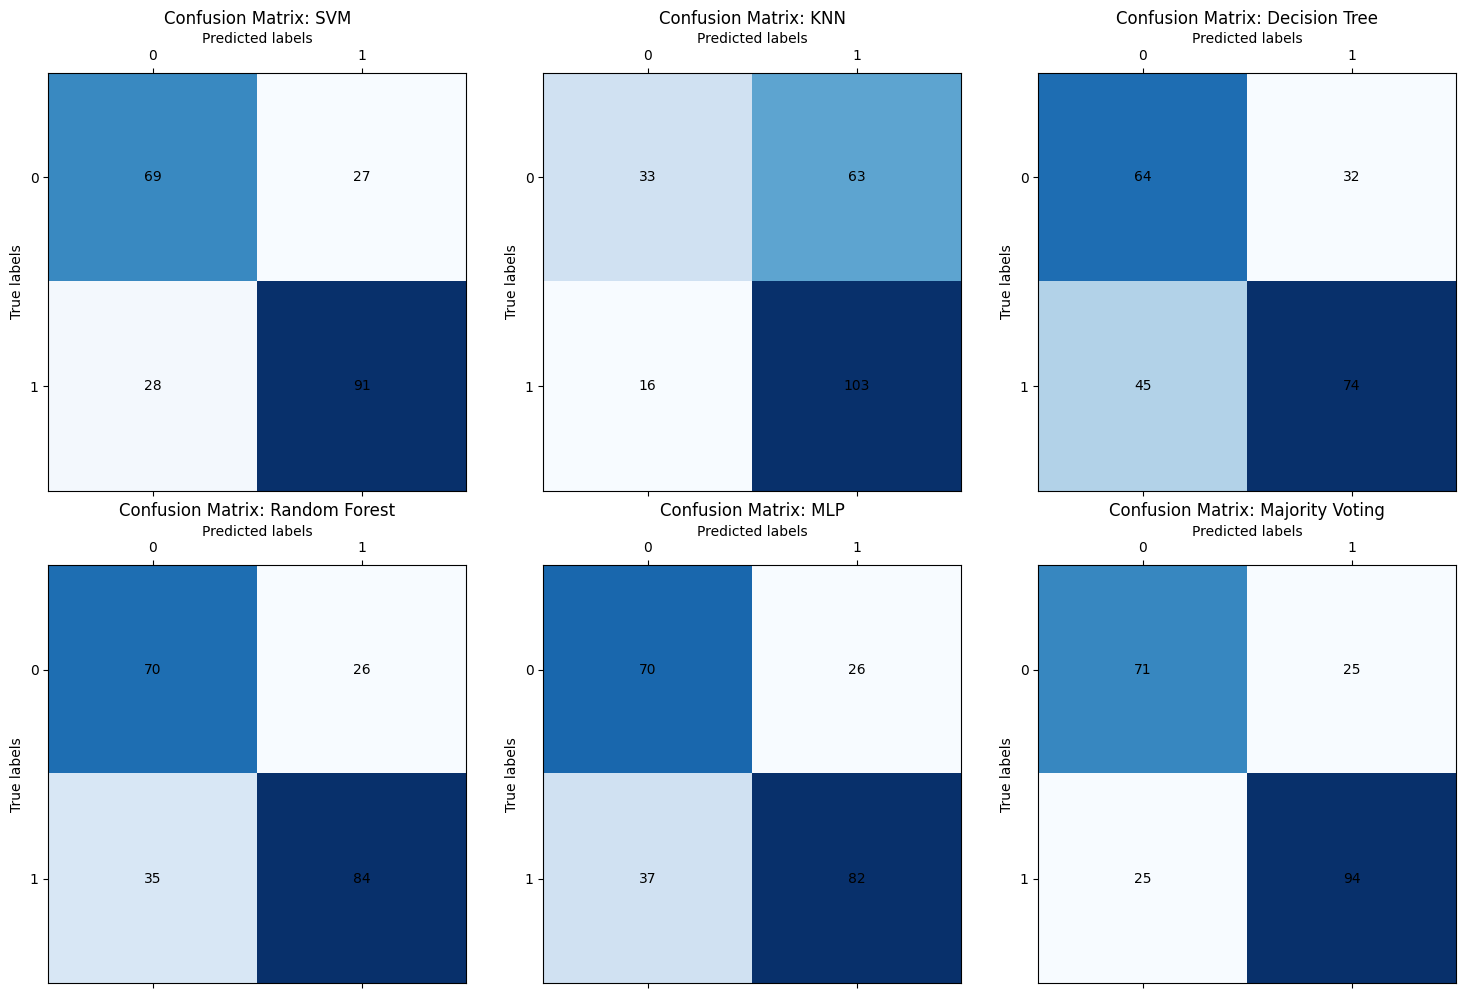

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
from scipy.stats import mode
from collections import Counter

# 數據準備
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=69)

# 模型訓練
models = {
    'SVC': SVC(random_state=69),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=69),
    'Random Forest': RandomForestClassifier(random_state=69),
    'MLP': MLPClassifier(random_state=69, max_iter=1000)
}

# 預測和評估
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = {'Accuracy': acc, 'Confusion Matrix': confusion_matrix(y_test, y_pred)}
    print(f'{name} Model Accuracy: {acc:.2f}')

# 建立投票模型
# 將各模型對測試集的預測結果收集起來
predictions = [model.predict(X_test) for model in models.values()]  # list of arrays
predictions = np.array(predictions).T  # shape: (n_samples, n_models)

# 對每一個樣本投票，找出出現次數最多的類別
vote_predictions = []
for row in predictions:
    # row 形如 ["class1", "class2", ...]，用 Counter 找最多的
    most_common_label = Counter(row).most_common(1)[0][0]
    vote_predictions.append(most_common_label)

vote_predictions = np.array(vote_predictions)

# 評估投票後的結果
vote_accuracy = accuracy_score(y_test, vote_predictions)
vote_confusion_matrix = confusion_matrix(y_test, vote_predictions)
print(f'Majority Voting Accuracy: {vote_accuracy:.2f}')


# 繪製Confusion Matrix
def plot_confusion_matrix(cm, model_name, ax):
    ax.matshow(cm, cmap=plt.cm.Blues)
    ax.set_title('Confusion Matrix: ' + model_name)
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.xaxis.set_label_position('top')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    for (i, j), val in np.ndenumerate(cm):
        ax.text(j, i, f'{val}', ha='center', va='center')

fig, axs = plt.subplots(2, 3, figsize=(15, 10))
for ax, (model_name, result) in zip(axs.flatten(), results.items()):
    plot_confusion_matrix(result['Confusion Matrix'], model_name, ax)

plot_confusion_matrix(vote_confusion_matrix, 'Majority Voting', axs.flatten()[-1])
plt.tight_layout()
plt.show()


### 開始進行backtest

1. 篩選出所有有華城的新聞

In [ ]:
# 用全部的新聞和全部的變化 去建立模型

# 用 open + errors='replace' 打開並讀取整個檔案
import io
with open("bda2025_mid_dataset/mobile01clean.csv", encoding='big5', errors='replace') as f:
    content = f.read()
# 用 pandas 從讀入的字串建立 DataFrame
mobile01_df = pd.read_csv(io.StringIO(content))

news_df = pd.read_excel("bda2025_mid_dataset/新聞clean.xlsx")
dcard1_df = pd.read_csv("bda2025_mid_dataset/dcard_1clean.csv")
dcard2_df = pd.read_csv("bda2025_mid_dataset/dcard_2clean.csv")
ptt_df = pd.read_csv("bda2025_mid_dataset/pttclean.csv")

allnews_df = pd.concat([news_df, dcard1_df, dcard2_df, mobile01_df, ptt_df], ignore_index=True)

# 使用關鍵字“華城”篩選新聞
filtered_news = allnews_df[(allnews_df['title'].str.contains("華城")) | (allnews_df['content'].str.contains("華城"))]

# 保留需要的列並轉換post_time列為datetime格式
filtered_news = filtered_news[["post_time", "title", "content"]]
filtered_news['post_time'] = pd.to_datetime(filtered_news['post_time']).dt.date

filtered_news.to_csv('ft_all_news.csv', index=True)

2. 用助教示範的方式將每篇轉為向量  
用漲跌各2000字，重複就刪掉

In [44]:
# 各用2000個詞，只要重複就刪掉

import itertools

use_words = 2000
termset = []

with open('bullish_allwords.csv', newline='', encoding='utf-8') as f:
  rows = csv.reader(f, delimiter=',')
  # islice(rows, 2000) 會產生只含前 2000 行的迭代器
  for row in itertools.islice(rows, use_words):
    if row[0] not in termset:
      termset.append(row[0])
f.close()

with open('bearish_allwords.csv', newline='', encoding='utf-8') as f:
  rows = csv.reader(f, delimiter=',')
  # islice(rows, 2000) 會產生只含前 2000 行的迭代器
  for row in itertools.islice(rows, use_words):
    if row[0] not in termset:
      termset.append(row[0])
    else: termset.remove(row[0])
f.close()

print(len(termset))

602


In [50]:
import numpy as np

def news_to_vec(termset_list, content):
    # 建立特徵向量
    vector = [0] * len(termset_list)
    # 添加向量
    for index, word in enumerate(termset_list):
        # 計算詞在文章中的出現次數
        vector[index] = content.count(word)
    # 向量長度標準化
    length = np.linalg.norm(np.array(vector))
    if length != 0:
        vector = vector / length
    return vector

# 使用 news_to_vec 轉換每篇文章的 'title' 和 'content' 為向量
filtered_news['vector'] = filtered_news.apply(lambda x: news_to_vec(termset, x['title'] + " " + x['content']), axis=1)

filtered_news['date'] = pd.to_datetime(filtered_news['post_time']).dt.date
filtered_news.drop(columns = ['post_time'], inplace = True)
filtered_news

,Unnamed: 0,title,content,vector,date
0,21,盤中速報 - 華城(1519)股價大漲至51.8元，漲幅達7.25%,華城(1519-TW)03日11:07股價上漲3.5元，報51.8元，漲幅7.25%，成交1...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",2023-01-03
1,45,台股震盪收跌24.99點,（中央社台北4日電）台北股市今天震盪收跌，收盤跌24.99點，為14199.13點，跌幅0....,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",2023-01-04
2,46,台積電壓尾盤 台股收跌24.99點14200失守,（中央社記者韓婷婷台北4日電）台股今天在晶圓雙雄穩盤，百貨、造紙、光電、儲能、網通等族群衝鋒...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",2023-01-04
3,48,台股終場小跌24點 光電族群續發威,[NOWnews今日新聞]美股2023年首個交易日4大指數皆走跌，台北股市今（4）日終場小跌...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",2023-01-04
4,53,台股多空交戰失守14200點 三大法人土洋對作賣超42.5億元,台股今 (4) 日在平盤上下遊走，光電族群表現強勢，其中，再生能源族群成為盤面多頭指標，不過...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",2023-01-04
...,...,...,...,...,...
4423,661626,[情報] 0224 上市櫃外資投信買超金額排行,外資 排行 股票名稱 收盤價 漲跌 買超(百萬) 1 260...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",2025-02-24
4424,661755,参加老蘇和訂閱哲哲之比較,最近哲哲一直上新聞，所以也來分享ㄧ下心得。 2022年我参加老蘇會員，結果白忙一場。 相關新...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",2025-02-26
4425,661828,[標的] 1618 合機 電纜教多,標的： 1618 合機 分類：多 分析/正文： 基本面： 主要產品 1.交連PE電纜...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",2025-02-27
4426,661874,[情報] 0227 上市投信買賣超排行,1. 標題：投信買賣超排行 2. 來源：富邦證券 3. 網址：https://tinyu...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",2025-02-27


In [ ]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import VotingClassifier
from dateutil.relativedelta import relativedelta
from sklearn.metrics import accuracy_score
from datetime import datetime, timedelta
import ast

def moving_backtest(news_data, transaction_data):
    start_date = news_data['date'].min()
    end_date = news_data['date'].max()

    current_date = start_date
    pred_df = pd.DataFrame({'y_test': pd.Series(), 'y_pred': pd.Series()})

    # 初始化分類器
    svc = SVC(probability=True)
    knn = KNeighborsClassifier()
    decision_tree = DecisionTreeClassifier()
    random_forest = RandomForestClassifier()
    mlp = MLPClassifier()

    # 使用VotingClassifier進行投票
    voting_clf = VotingClassifier(
        estimators=[
            ('svc', svc),
            ('knn', knn),
            ('decision_tree', decision_tree),
            ('random_forest', random_forest),
            ('mlp', mlp)
        ],
        voting='soft'
    )
    
    # 假設你的 news_data 有欄位 'date' (字串日期) 與 'vector' (多維度嵌入向量)
    # 可能需要先把 'vector' 這欄轉成 list
    news_data['vector'] = news_data['vector'].apply(
        lambda x: ast.literal_eval(x) if isinstance(x, str) else x
    )

    # 1) 把日期轉成 datetime
    news_data['date'] = pd.to_datetime(news_data['date']).dt.date  # 只取 YYYY-MM-DD
    transaction_data['年月日'] = pd.to_datetime(transaction_data['年月日']).dt.date

    # 2) 先對 news_data 進行 groupby，每天彙整成一個向量
    #  例如 "每篇新聞的向量做平均"
    def mean_vector(vec_series):
        # vec_series 是同一天多篇新聞的 vector(list) 聚合在一起
        # shape 可能是 (多篇, 向量維度) -> 我們把它 stack 起來，再 mean
        arr = np.stack(vec_series.values, axis=0)  # shape = (N, D)
        return arr.mean(axis=0)                   # shape = (D, )

    news_daily = news_data.groupby('date', as_index=False).agg({'vector': mean_vector})

    # 3) 現在 news_daily 每天只剩 1 筆 (date, vector)，
    #    transaction_data 也是每個交易日一筆 (年月日, Change)，
    #    我們可以 merge 起來
    merged = pd.merge(
        news_daily,                       # (date, vector)
        transaction_data,                 # (年月日, Change)
        how='inner',                      # 僅保留雙方都有的日期
        left_on='date', right_on='年月日'
    )
    # merged 會有:
    #    date, vector, 年月日, Change
    # 其中 date == 年月日

    # 4) 把 vector 攤開成 2D numpy array (X)，Change 則是 y
    X = np.stack(merged['vector'].values, axis=0)   # shape (天數, 向量維度)
    y = merged['Change'].values                     # shape (天數, )

    # 5) 這樣就有對齊的 X, y，可以再進一步分割成 train / test

    while current_date + relativedelta(months=4) <= end_date:
        train_start = current_date.replace(day=1)
        train_end = (train_start + relativedelta(months=3)).replace(day=1) - timedelta(days=1)
        test_start = (train_start + relativedelta(months=3)).replace(day=1)
        test_end = (test_start + relativedelta(months=1)).replace(day=1) - timedelta(days=1)

        # 拆分數據集為訓練集和測試集 (前三個月訓練，最後一個月測試)
        train_mask = (merged['date'] >= train_start) & (merged['date'] <= train_end)
        X_train_series = merged.loc[train_mask, 'vector']      # 先取出 series (list of lists)
        y_train = merged.loc[train_mask, 'Change'].values      # ndarray (N, )

        # 將 list of lists 轉為 2D numpy array
        # shape -> (N, D)
        if len(X_train_series) > 0:
            X_train = np.stack(X_train_series.values, axis=0)
        else:
            # 如果沒有資料，可視需求跳過或結束
            current_date += relativedelta(months=1)
            continue

        # === 同理，取出 X_test, y_test ===
        test_mask = (merged['date'] >= test_start) & (merged['date'] <= test_end)
        X_test_series = merged.loc[test_mask, 'vector']
        y_test = merged.loc[test_mask, 'Change'].values

        if len(X_test_series) > 0:
            X_test = np.stack(X_test_series.values, axis=0)
        else:
            current_date += relativedelta(months=1)
            continue

        # 訓練模型
        voting_clf.fit(X_train, y_train)

        # 在測試集上進行預測
        y_pred = voting_clf.predict(X_test)

        # 計算準確率
        accuracy = accuracy_score(y_test, y_pred)
        print(f'{current_date} accuracy: {accuracy}')

        pred_df = pd.concat([pred_df, pd.DataFrame({'y_test': y_test, 'Change': y_pred})], ignore_index=True)

        current_date += relativedelta(months=1)

    return pred_df

Backtest_MTK_transaction_df = pd.read_csv('FT_all_trans.csv')

result = moving_backtest(filtered_news, Backtest_MTK_transaction_df)
result


c:\Users\jason\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


2023-01-03 accuracy: 0.35294117647058826


c:\Users\jason\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


2023-02-03 accuracy: 0.5


c:\Users\jason\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


...

2024-08-03 accuracy: 0.65


c:\Users\jason\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


2024-09-03 accuracy: 0.5789473684210527
2024-10-03 accuracy: 0.7272727272727273


c:\Users\jason\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


,y_test,y_pred,Change
0,2,NaN,0.0
1,2,NaN,0.0
2,2,NaN,0.0
3,2,NaN,2.0
4,2,NaN,2.0
...,...,...,...
424,0,NaN,0.0
425,0,NaN,0.0
426,2,NaN,2.0
427,2,NaN,0.0
